<a href="https://colab.research.google.com/github/devisha-jain/Fashion-Forcasting-Lab/blob/main/Minor_project_2_devishajain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)




Shape: (200, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [6]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for col in features:
  print(f"\n{col}")
  print("Mean:", df[col].mean())
  print("Median:", df[col].median())
  print("Std Dev:", df[col].std())



Age
Mean: 38.85
Median: 36.0
Std Dev: 13.969007331558883

Annual Income (k$)
Mean: 60.56
Median: 61.5
Std Dev: 26.264721165271254

Spending Score (1-100)
Mean: 50.2
Median: 50.0
Std Dev: 25.823521668370162


In [7]:
# feature showing highest variability
df[features].std()


,0
Age,13.969007
Annual Income (k$),26.264721
Spending Score (1-100),25.823522


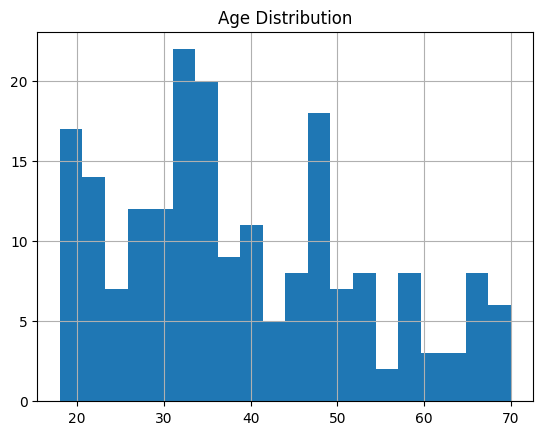

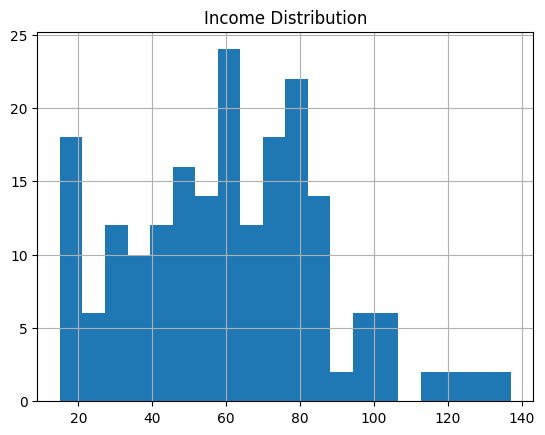

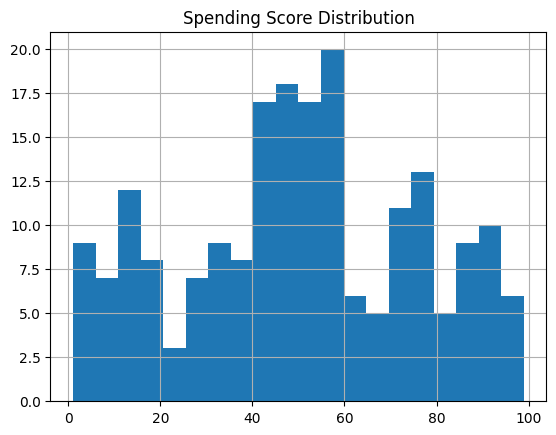

In [8]:
import matplotlib.pyplot as plt

df['Age'].hist(bins=20)
plt.title("Age Distribution")
plt.show()

df['Annual Income (k$)'].hist(bins=20)
plt.title("Income Distribution")
plt.show()

df['Spending Score (1-100)'].hist(bins=20)
plt.title("Spending Score Distribution")
plt.show()



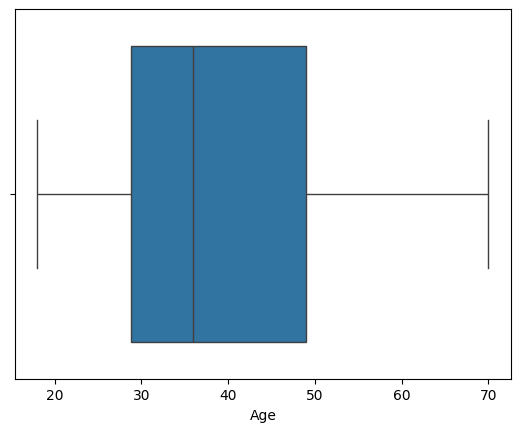

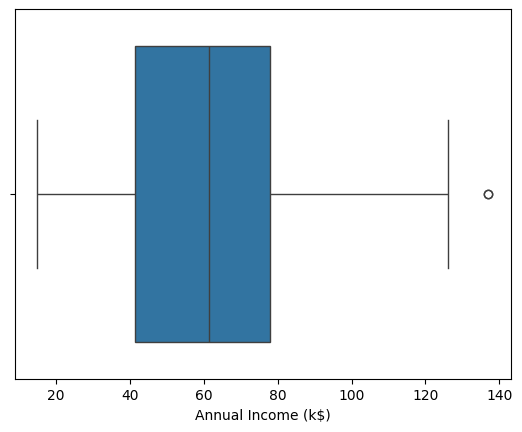

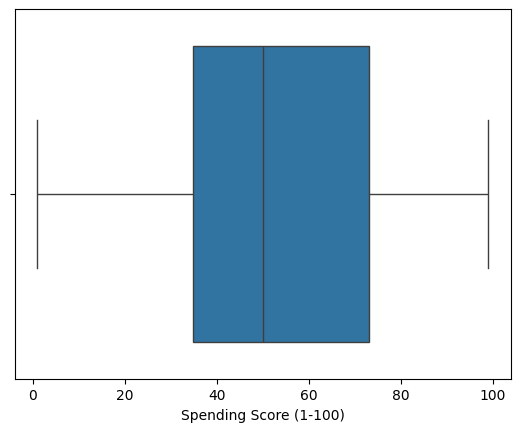

In [9]:
import seaborn as sns

sns.boxplot(x=df['Age'])
plt.show()

sns.boxplot(x=df['Annual Income (k$)'])
plt.show()

sns.boxplot(x=df['Spending Score (1-100)'])
plt.show()

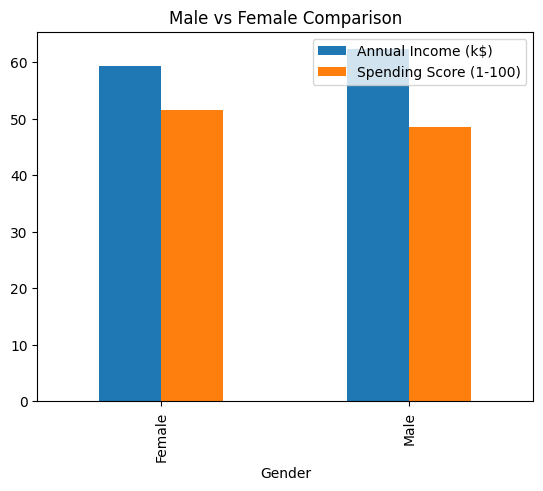

In [10]:
gender_group = df.groupby('Gender').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
})

gender_group.plot(kind='bar')
plt.title("Male vs Female Comparison")
plt.show()


In [11]:
corr = df[['Age','Annual Income (k$)','Spending Score (1-100)']].corr()
print(corr)

                             Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000000           -0.012398               -0.327227
Annual Income (k$)     -0.012398            1.000000                0.009903
Spending Score (1-100) -0.327227            0.009903                1.000000


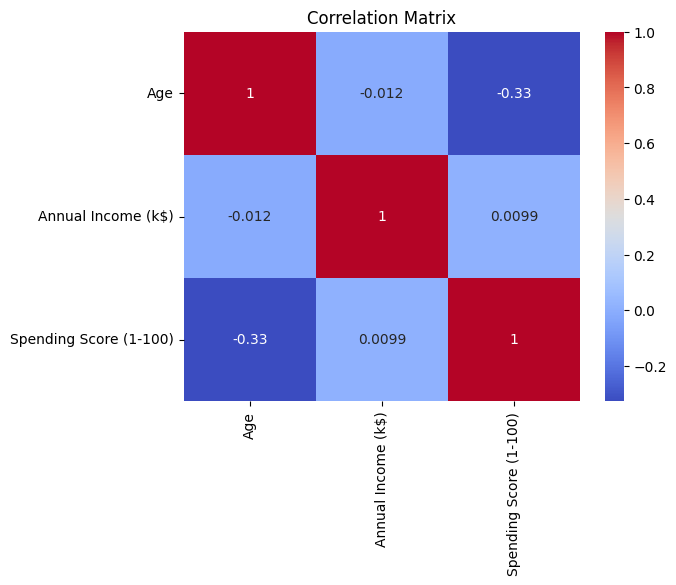

In [12]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [13]:
from scipy import stats

male = df[df['Gender']=='Male']['Spending Score (1-100)']
female = df[df['Gender']=='Female']['Spending Score (1-100)']
t_stat, p_value = stats.ttest_ind(male, female)
print("T-statistic:",t_stat)
print("P-value:", p_value)

T-statistic: -0.8190464150660334
P-value: 0.4137446589852174


In [14]:
alpha = 0.05

if p_value < alpha:
  print("Reject H0")
else:
  print("Fail to Reject H0")

Fail to Reject H0


In [16]:
import scipy.stats as st
import numpy as np
spending = df['Spending Score (1-100)']

mean = np.mean(spending)
std = np.std(spending, ddof=1)
n = len(spending)

confidence = 0.95

margin_error = st.t.ppf(
    (1 + confidence) / 2,
    n-1
) * (std / np.sqrt(n))

lower = mean - margin_error
upper = mean + margin_error

print("95% confidence Interval:")
print(lower, upper)

95% confidence Interval:
46.599209857381204 53.8007901426188


Section-8.
The business should target customers with
1. high spending score
2. Moderate to high income
3. Frequent purchasing behaviour
* The income does influence the spending.
Based on t-test gender-specific campaigns are recommended, and there is uniform marketing strategy.


*  Premium Segment- The Suggested strategy is that we target high income and high spending customers with exclusive offers, VIP memberships and Loyalty programs


*   Medium Segment- we use seasonal discounts and bundle offers for this one
*   Low-Spending Segment- Encouragement of purchases through coupons cashback rewards and personalized recommendations



